In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading and Initial Exploration

In [ ]:
df = pd.read_csv("ipl.csv")
df.head(5)

,team1,team2,match_date,toss_winner,toss_decision,winner,player_of_match,venue,city,team1_players,team2_players,season,match_number,match_type,result,result_margin,target_runs,target_overs,super_over
0,Royal Challengers Bangalore,Kolkata Knight Riders,2008-04-18,Royal Challengers Bangalore,field,Kolkata Knight Riders,BB McCullum,M Chinnaswamy Stadium,Bangalore,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey...",1,1,League,runs,140.0,223.0,20.0,N
1,Kings XI Punjab,Chennai Super Kings,2008-04-19,Chennai Super Kings,bat,Chennai Super Kings,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Chandigarh,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ...",1,2,League,runs,33.0,241.0,20.0,N
2,Delhi Daredevils,Rajasthan Royals,2008-04-19,Rajasthan Royals,bat,Delhi Daredevils,MF Maharoof,Feroz Shah Kotla,Delhi,"G Gambhir, V Sehwag, S Dhawan, MK Tiwary, KD K...","T Kohli, YK Pathan, SR Watson, M Kaif, DS Lehm...",1,3,League,wickets,9.0,130.0,20.0,N
3,Mumbai Indians,Royal Challengers Bangalore,2008-04-20,Mumbai Indians,bat,Royal Challengers Bangalore,MV Boucher,Wankhede Stadium,Mumbai,"L Ronchi, ST Jayasuriya, DJ Thornely, RV Uthap...","S Chanderpaul, R Dravid, LRPL Taylor, JH Kalli...",1,4,League,wickets,5.0,166.0,20.0,N
4,Kolkata Knight Riders,Deccan Chargers,2008-04-20,Deccan Chargers,bat,Kolkata Knight Riders,DJ Hussey,Eden Gardens,Kolkata,"WP Saha, BB McCullum, RT Ponting, SC Ganguly, ...","AC Gilchrist, Y Venugopal Rao, VVS Laxman, A S...",1,5,League,wickets,5.0,111.0,20.0,N


In [155]:
df.shape

(1169, 19)

In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1169 entries, 0 to 1168
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   team1            1169 non-null   object 
 1   team2            1169 non-null   object 
 2   match_date       1169 non-null   object 
 3   toss_winner      1169 non-null   object 
 4   toss_decision    1169 non-null   object 
 5   winner           1146 non-null   object 
 6   player_of_match  1169 non-null   object 
 7   venue            1169 non-null   object 
 8   city             1118 non-null   object 
 9   team1_players    1169 non-null   object 
 10  team2_players    1169 non-null   object 
 11  season           1169 non-null   int64  
 12  match_number     1169 non-null   int64  
 13  match_type       1169 non-null   object 
 14  result           1169 non-null   object 
 15  result_margin    1146 non-null   float64
 16  target_runs      1163 non-null   float64
 17  target_overs  

In [157]:
df.describe()

,season,match_number,result_margin,target_runs,target_overs
count,1169.000000,1169.000000,1146.000000,1163.000000,1163.000000
mean,9.687767,33.359281,17.364747,167.253654,19.768014
std,5.253100,19.430749,21.919255,34.222771,1.542583
min,1.000000,1.000000,1.000000,43.000000,5.000000
25%,5.000000,17.000000,6.000000,147.000000,20.000000
50%,10.000000,33.000000,8.000000,167.000000,20.000000
75%,15.000000,49.000000,20.000000,188.000000,20.000000
max,18.000000,76.000000,146.000000,288.000000,20.000000


In [158]:
df.columns

Index(['team1', 'team2', 'match_date', 'toss_winner', 'toss_decision',
       'winner', 'player_of_match', 'venue', 'city', 'team1_players',
       'team2_players', 'season', 'match_number', 'match_type', 'result',
       'result_margin', 'target_runs', 'target_overs', 'super_over'],
      dtype='object')

In [159]:
df = df.drop(columns=[
    "team1_players",
    "team2_players",
    "match_number",
    "target_runs",
    "target_overs"
])
df

,team1,team2,match_date,toss_winner,toss_decision,winner,player_of_match,venue,city,season,match_type,result,result_margin,super_over
0,Royal Challengers Bangalore,Kolkata Knight Riders,2008-04-18,Royal Challengers Bangalore,field,Kolkata Knight Riders,BB McCullum,M Chinnaswamy Stadium,Bangalore,1,League,runs,140.0,N
1,Kings XI Punjab,Chennai Super Kings,2008-04-19,Chennai Super Kings,bat,Chennai Super Kings,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Chandigarh,1,League,runs,33.0,N
2,Delhi Daredevils,Rajasthan Royals,2008-04-19,Rajasthan Royals,bat,Delhi Daredevils,MF Maharoof,Feroz Shah Kotla,Delhi,1,League,wickets,9.0,N
3,Mumbai Indians,Royal Challengers Bangalore,2008-04-20,Mumbai Indians,bat,Royal Challengers Bangalore,MV Boucher,Wankhede Stadium,Mumbai,1,League,wickets,5.0,N
4,Kolkata Knight Riders,Deccan Chargers,2008-04-20,Deccan Chargers,bat,Kolkata Knight Riders,DJ Hussey,Eden Gardens,Kolkata,1,League,wickets,5.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1164,Lucknow Super Giants,Royal Challengers Bengaluru,2025-05-27,Royal Challengers Bengaluru,field,Royal Challengers Bengaluru,JM Sharma,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow,18,League,wickets,6.0,N
1165,Punjab Kings,Royal Challengers Bengaluru,2025-05-29,Royal Challengers Bengaluru,field,Royal Challengers Bengaluru,Suyash Sharma,Maharaja Yadavindra Singh International Cricke...,New Chandigarh,18,Qualifier 1,wickets,8.0,N
1166,Mumbai Indians,Gujarat Titans,2025-05-30,Mumbai Indians,bat,Mumbai Indians,RG Sharma,Maharaja Yadavindra Singh International Cricke...,New Chandigarh,18,Eliminator,runs,20.0,N
1167,Mumbai Indians,Punjab Kings,2025-06-01,Punjab Kings,field,Punjab Kings,SS Iyer,"Narendra Modi Stadium, Ahmedabad",Ahmedabad,18,Qualifier 2,wickets,5.0,N


## Data Cleaning and Preprocessing

In [160]:
team_map = {
    "Kings XI Punjab": "Punjab Kings",
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru",
    "Rising Pune Supergiant": "Rising Pune Supergiants",
    "Delhi Daredevils": "Delhi Capitals",
    "Elimination Final":"Eliminator",
    "Qualifier 1": "Semi Final",
    "Qualifier 2": "Semi Final"

}

df = df.replace(team_map)

In [161]:
def venue_name(name):
  name = name.split(",")
  return name[0]

df['venue'] = df['venue'].apply(venue_name)

In [162]:
stadium_map = {
    "Feroz Shah Kotla": "Arun Jaitley Stadium",
    "M.Chinnaswamy Stadium": "M Chinnaswamy Stadium",
    "Sardar Patel Stadium": "Narendra Modi Stadium",
    "Punjab Cricket Association Stadium": "Punjab Cricket Association IS Bindra Stadium",
    "Zayed Cricket Stadium": "Sheikh Zayed Stadium",
    "Subrata Roy Sahara Stadium": "Maharashtra Cricket Association Stadium",
}

df['venue'] = df['venue'].replace(stadium_map)

## Exploratory Data Analysis (EDA)

In [163]:
team_colors = {
    "Mumbai Indians": "#004BA0",
    "Chennai Super Kings": "#F9CD05",
    "Royal Challengers Bengaluru": "#EC1C24",
    "Kolkata Knight Riders": "#3A225D",
    "Delhi Capitals": "#0078BC",
    "Rajasthan Royals": "#FF2E63",
    "Punjab Kings": "#ED1B24",
    "Sunrisers Hyderabad": "#FF822A",
    "Lucknow Super Giants": "#00A3E0",
    "Gujarat Titans": "#1B1F3B",

    # discontinued teams
    "Deccan Chargers": "#0081A7",
    "Pune Warriors": "#6A4C93",
    "Rising Pune Supergiants": "#A41623",
    "Gujarat Lions": "#F77F00",
    "Kochi Tuskers Kerala": "#2A9D8F"
}

**Most wins by a team**

In [164]:
winner_list = df["winner"].value_counts()

Text(0, 0.5, 'Most wins till 2025')

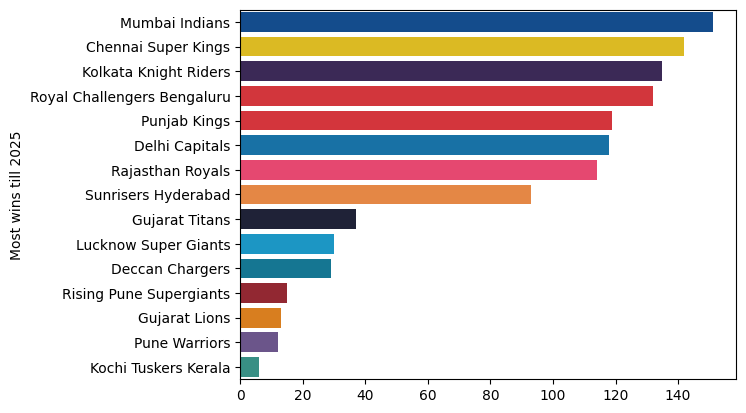

In [165]:
sns.barplot(x=winner_list.values, y=winner_list.index,hue = winner_list.index, legend = False, palette = team_colors)
plt.ylabel("Most wins till 2025")

**Most toss wins**

In [166]:
toss_winner_list = df["toss_winner"].value_counts()

Text(0, 0.5, 'Most toss wins till 2025')

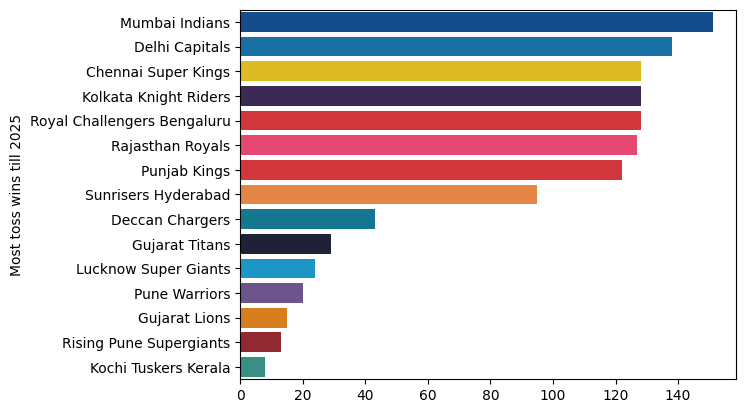

In [167]:
sns.barplot(x=toss_winner_list.values, y=toss_winner_list.index,hue = toss_winner_list.index, legend = False, palette = team_colors)
plt.ylabel("Most toss wins till 2025")

### Team Performance Analysis

**Most losses**

In [168]:
team1 = df[df['team1'] != df['winner']]['team1']
team2 = df[df['team2'] != df['winner']]['team2']
most_loss = pd.concat([team1, team2]).value_counts()


Text(0, 0.5, 'Most losses')

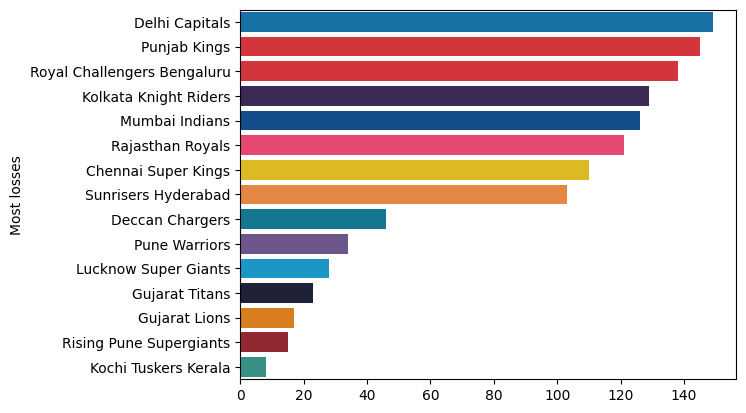

In [169]:
sns.barplot(x = most_loss.values,y=most_loss.index,hue = most_loss.index,legend=False, palette = team_colors )
plt.ylabel("Most losses")

**Most toss loss**

In [170]:
toss_team1 = df[df['team1'] != df['toss_winner']]['team1']
toss_team2 = df[df['team2'] != df['toss_winner']]['team2']
most_toss_loss = pd.concat([toss_team1, toss_team2]).value_counts()

Text(0, 0.5, 'Most toss losses')

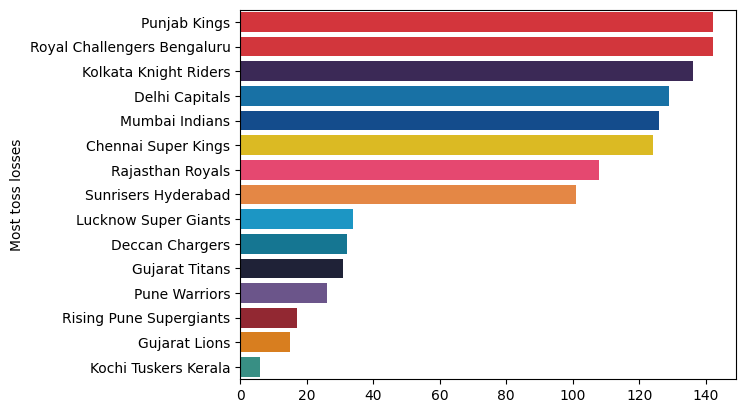

In [171]:
sns.barplot(x = most_toss_loss.values,y=most_toss_loss.index,hue = most_toss_loss.index,legend=False,palette = team_colors )
plt.ylabel("Most toss losses")

### Match Related Analysis

**Most games played**

In [172]:
matches_played = pd.concat([df['team1'],df['team2']]).value_counts()


Text(0, 0.5, 'Most games played')

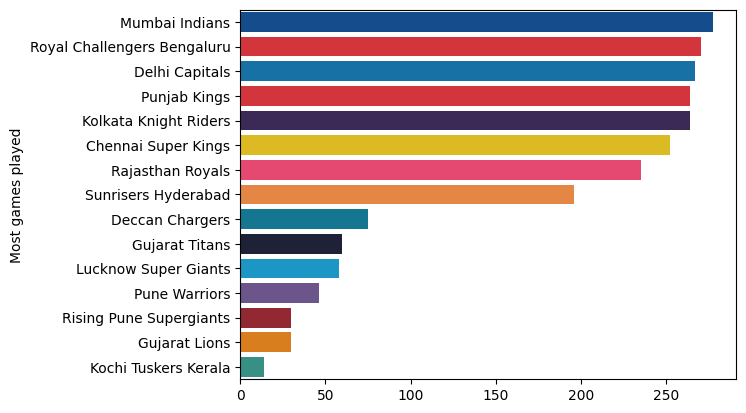

In [173]:
sns.barplot(x = matches_played.values,y = matches_played.index,hue = matches_played.index,legend=False, palette = team_colors)
plt.ylabel("Most games played")

**Most league games played**

In [174]:
match_type = pd.concat([df[['match_type','team1']].rename(columns={"team1": "team"}),
               df[['match_type','team2']].rename(columns={"team2": "team"}),
               ])
match_type = match_type.groupby("match_type").value_counts()

playoff = pd.concat([match_type["Eliminator"],match_type["Semi Final"],match_type["Final"]])
playoff = playoff.groupby(playoff.index).sum()

In [175]:
eliminator_match_type = match_type["Eliminator"]
semifinal_match_type = match_type["Semi Final"]
final_match_type = match_type["Final"]

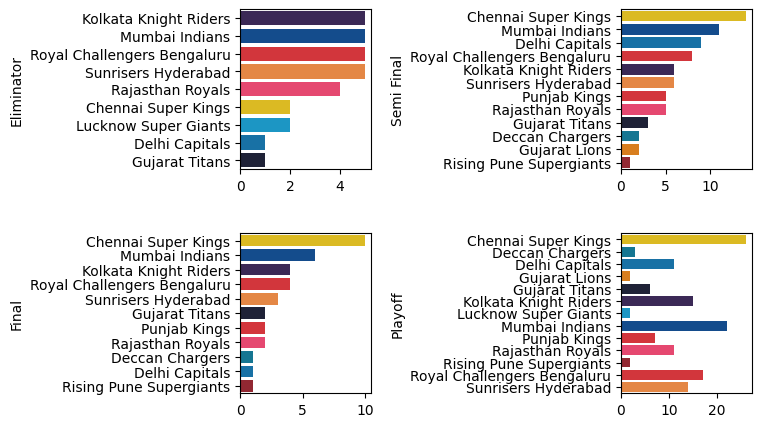

In [176]:
plt.subplot(2,2,1)
sns.barplot(x = eliminator_match_type.values,y = eliminator_match_type.index, hue=eliminator_match_type.index, legend =False, palette = team_colors )
plt.ylabel("Eliminator")
plt.subplot(2,2,2)
sns.barplot(x = semifinal_match_type.values,y = semifinal_match_type.index, hue=semifinal_match_type.index, legend =False, palette = team_colors)
plt.ylabel("Semi Final")
plt.subplot(2,2,3)
sns.barplot(x = final_match_type.values,y = final_match_type.index,hue=final_match_type.index, legend =False, palette = team_colors)
plt.ylabel("Final")
plt.subplot(2,2,4)
sns.barplot(x=playoff.values, y = playoff.index, hue = playoff.index,legend =False, palette = team_colors)
plt.ylabel("Playoff")
plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=1.9, hspace=0.4)

### Player Performance Analysis

**Most player of the match**

In [177]:
potm_list = df['player_of_match'].value_counts()
potm_list.head(10).index

Index(['AB de Villiers', 'CH Gayle', 'RG Sharma', 'V Kohli', 'DA Warner',
       'MS Dhoni', 'SP Narine', 'AD Russell', 'SR Watson', 'YK Pathan'],
      dtype='object', name='player_of_match')

Text(0, 0.5, 'Most Player of the match')

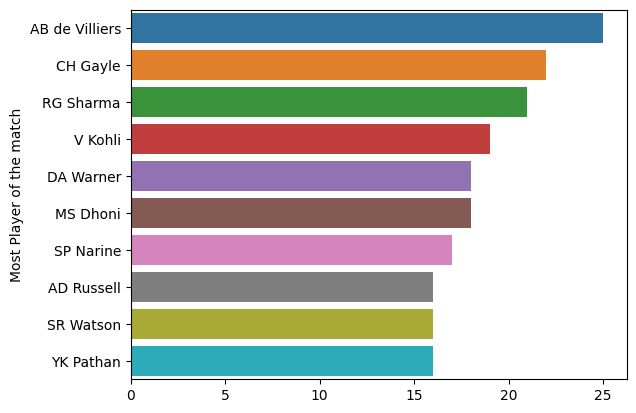

In [178]:
sns.barplot(x = potm_list.head(10).values, y =potm_list.head(10).index,hue= potm_list.head(10).index,legend = False )
plt.ylabel("Most Player of the match")

**Toss decisions**

In [179]:
toss_desicions = df['toss_decision'].value_counts()
percentage = (toss_desicions/toss_desicions.sum())*100
percentage = round(percentage , 2)
percentage

,count
toss_decision,
field,65.36
bat,34.64


Text(0.5, 1.0, 'Toss Decisions')

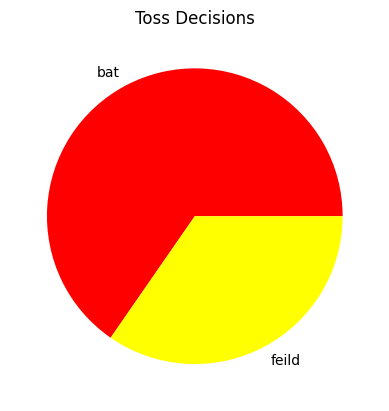

In [180]:
plt.pie(percentage,labels=["bat","feild"], colors=["red","yellow"])
plt.title("Toss Decisions")

### Toss and Match Outcome Analysis

**Toss win impact**


In [181]:
win_by_toss = df[df['toss_winner'] == df['winner']]
win_by_toss = win_by_toss['winner'].value_counts()

Text(0, 0.5, 'Toss win impact')

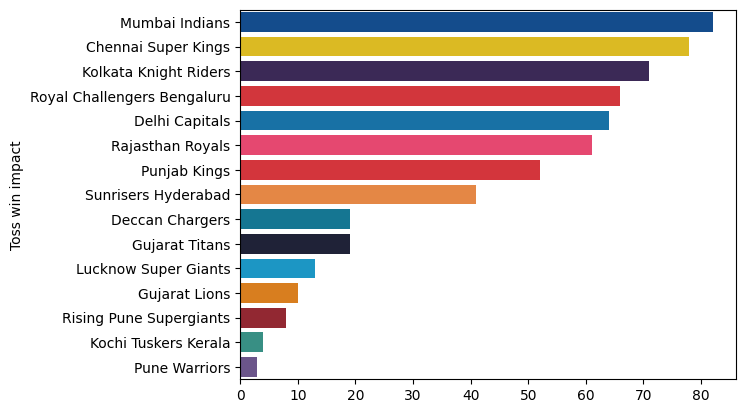

In [182]:
sns.barplot(x = win_by_toss.values, y = win_by_toss.index, hue=win_by_toss.index, legend=False, palette=team_colors)
plt.ylabel("Toss win impact")

**Win while bat first**

In [183]:
win_bat_first = df.groupby('toss_decision')['winner'].value_counts()['bat']
win_bat_first

,count
winner,
Chennai Super Kings,65
Mumbai Indians,53
Kolkata Knight Riders,51
Delhi Capitals,43
Rajasthan Royals,42
Royal Challengers Bengaluru,38
Sunrisers Hyderabad,31
Punjab Kings,30
Deccan Chargers,14


**Win bowl first**

In [184]:
win_bowl_first = df.groupby('toss_decision')['winner'].value_counts()['field']
win_bowl_first

,count
winner,
Mumbai Indians,98
Royal Challengers Bengaluru,94
Punjab Kings,89
Kolkata Knight Riders,84
Chennai Super Kings,77
Delhi Capitals,75
Rajasthan Royals,72
Sunrisers Hyderabad,62
Gujarat Titans,28


Text(0, 0.5, 'Win bowl first')

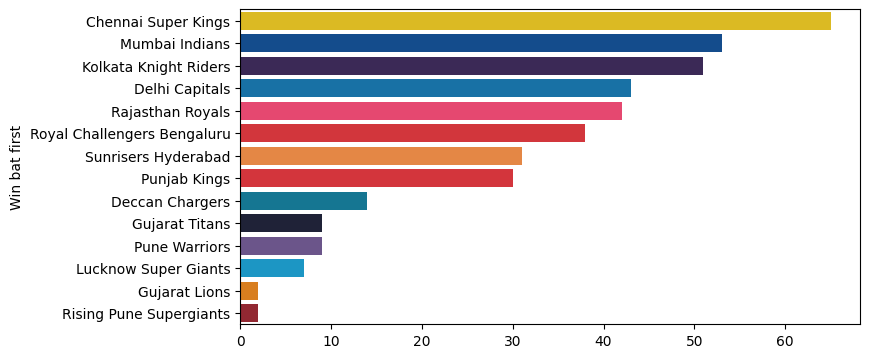

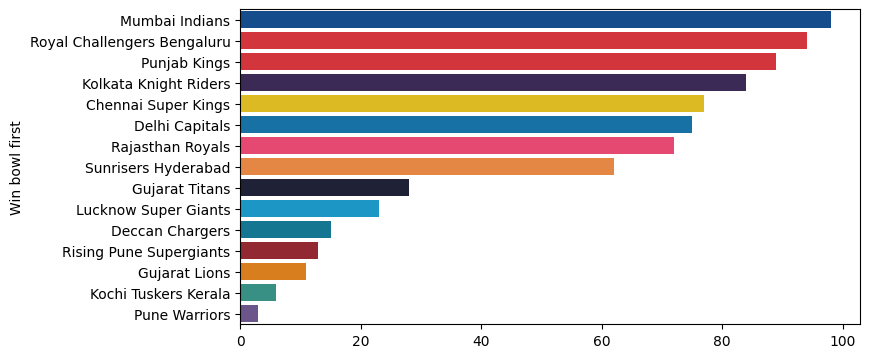

In [185]:
plt.figure(figsize=(8,9))
plt.subplot(2,1,1)
sns.barplot(x = win_bat_first.values, y = win_bat_first.index, hue = win_bat_first.index, legend = False, palette = team_colors)
plt.ylabel("Win bat first")
plt.figure(figsize=(8,9))
plt.subplot(2,1,2)
sns.barplot(x = win_bowl_first.values, y = win_bowl_first.index, hue = win_bowl_first.index, legend = False, palette = team_colors)
plt.ylabel("Win bowl first")



### Venue Analysis

**Games at each venue**

In [187]:
venues = df['venue'].value_counts()
venues

,count
venue,
Wankhede Stadium,125
Eden Gardens,100
M Chinnaswamy Stadium,99
Arun Jaitley Stadium,97
MA Chidambaram Stadium,91
Rajiv Gandhi International Stadium,83
Sawai Mansingh Stadium,64
Punjab Cricket Association IS Bindra Stadium,61
Maharashtra Cricket Association Stadium,51


<Axes: ylabel='venue'>

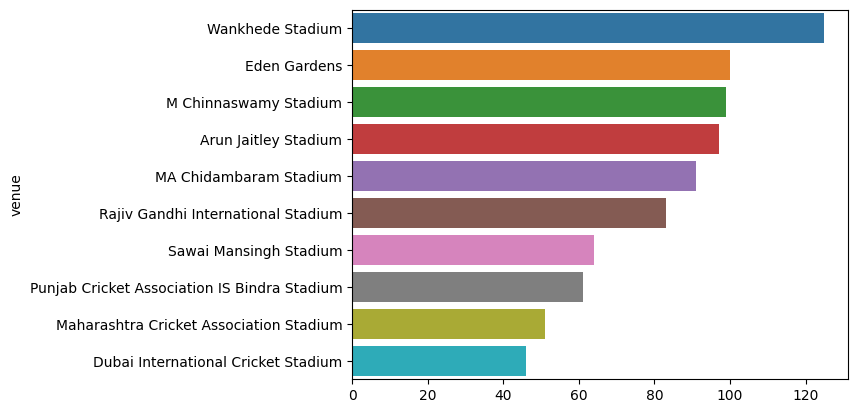

In [191]:
sns.barplot(x = venues.head(10).values, y = venues.head(10).index, hue = venues.head(10).index, legend = False)

### Season Analysis

**Matches played each season**

In [194]:
season_matches = df['season'].value_counts()
season_matches.sort_index(ascending = True)

,count
season,
1,58
2,57
3,60
4,73
5,74
6,76
7,60
8,59
9,60


Text(0.5, 0, 'Matches each season')

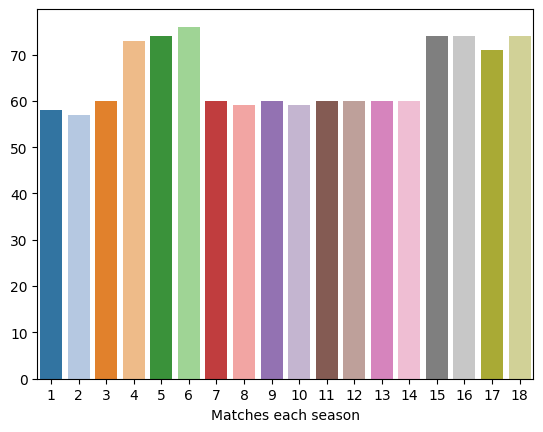

In [205]:
sns.barplot(x = season_matches.index, y = season_matches.values, hue=season_matches.index, legend = False , palette="tab20")
plt.xlabel("Matches each season")